## Bulk entrainment graph comparison 

In [3]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
from matplotlib.lines import Line2D

# Use given style and color maps
from colors import (
    mixing_c_map,
    label_map,
    author_color,
    marker_style,
)

plt.style.use("james2026lock.mplstyle")

# constants
rho_water = 998.2  # Freshwater density [kg/m³]
rho_bent = 2277  # Wetted bentonite density [kg/m³]
h0 = 0.25  # initial water height [m]
l0 = 0.27  # mixing chamber length [m]
v0 = h0 * l0
visc = 1e-3  # dynamic viscosity of water [Pa·s]
a_thresh = 0.06  # m/s² for example (below this velocity taken as roughly constant)

# load experiment table
metadata = pd.read_csv("../../data/metadata/metadata.csv")
compare_data = pd.read_csv("../../data/metadata/literature_comparison.csv")
folder = "../../data/datafiles"

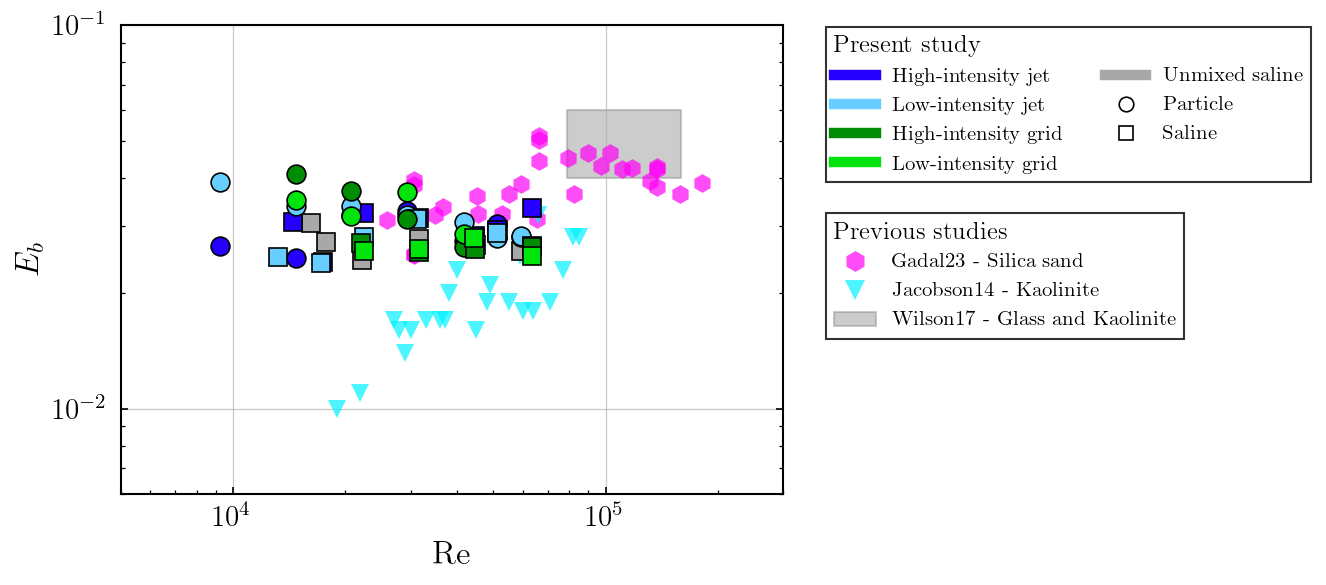

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# ===== plot my data ==========
for _, row in metadata.iterrows():
    data = np.load(f"{folder}/{row.exp_code}.npy", allow_pickle=True).item()
    fronts = np.abs(data["front_m"])
    areas = np.abs(data["area_m2"])
    heights = np.abs(data["height_m"])

    h_array = heights[-1, :]
    h_array = h_array[h_array > 0]
    x_tank = fronts[-1]
    x_array = np.linspace(0, x_tank, len(h_array))

    interfacial_length = np.trapz(
        np.sqrt(1 + np.gradient(h_array, x_array) ** 2), x_array
    )

    E = (areas[-1] - h0 * l0) / (x_tank * interfacial_length)
    re = (row.u_0 * 0.25 * row.rho) / visc

    color = mixing_c_map.get(row.mixing, "gray")
    ax.loglog(
        re,
        E,
        marker="o" if row.type == "part" else "s",
        markersize=9,
        color=color,
        markeredgecolor="k",
        markeredgewidth=0.8,
        zorder=5,
        linestyle="",
    )

# plot comparison data
for (author, ptype), group in compare_data.groupby(["author", "particle_type"]):
    re = group["Re"].values
    E = group["E"].values
    # skip if re or E is nan
    if np.isnan(re).all() or np.isnan(E).all():
        continue

    marker = marker_style.get(ptype, "o")
    color = author_color.get(author, "k")

    ax.plot(re, E, marker=marker, linestyle="", color=color, alpha=0.7, markersize=9)


w_data = compare_data[compare_data["short_name"] == "Wilson17"]
w_re_min = w_data["Re"].min()
w_re_max = w_data["Re"].max()
w_E_min = 0.04
w_E_max = 0.06
ax.fill_betweenx(
    [w_E_min, w_E_max], w_re_min, w_re_max, color="gray", alpha=0.4, zorder=0
)

# ===== build combined legend =====


my_legend_elements = [
    *[
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=5,
            label=label_map.get(mixing_type, mixing_type),
        )
        for mixing_type, color in mixing_c_map.items()
    ],
    # Line2D([0], [0], color="k", linestyle="--", linewidth=1.5, label="Best fit (all)"),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Particle",
        markerfacecolor="white",
        markeredgecolor="k",
        markeredgewidth=0.8,
        markersize=7,
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        label="Saline",
        markerfacecolor="white",
        markeredgecolor="k",
        markeredgewidth=0.8,
        markersize=7,
    ),
]

plotted_groups = [
    (author, short_name, ptype)
    for (author, short_name, ptype), group in compare_data.groupby(
        ["author", "short_name", "particle_type"]
    )
    if not (np.isnan(group["Re"].values).all() or np.isnan(group["E"].values).all())
]

compare_handles = [
    Line2D(
        [0],
        [0],
        marker=marker_style.get(ptype, "o"),
        color=author_color.get(author, "k"),
        label=f"{short_name} - {ptype}",
        linestyle="",
        markersize=10,
        alpha=0.7,
    )
    for author, short_name, ptype in plotted_groups
]

# sort compare handles by marker shape (saline last)
compare_handles.sort(key=lambda h: 1 if "Saline" in h.get_label() else 0)

# Wilson17 shaded region
wilson_handle = patches.Patch(
    color="gray", alpha=0.4, label="Wilson17 -  Glass and Kaolinite"
)

leg1 = fig.legend(
    handles=my_legend_elements,
    bbox_to_anchor=(0.95, 0.96),
    loc="upper left",
    ncols=2,
    fontsize=10,
    title="Present study",
)

leg2 = fig.legend(
    handles=compare_handles + [wilson_handle],
    bbox_to_anchor=(0.95, 0.65),
    loc="upper left",
    ncols=1,
    fontsize=10,
    title="Previous studies",
)

leg1._legend_box.align = "left"
leg2._legend_box.align = "left"

ax.set(ylim=([6e-3, 1e-1]), xlim=([5e3, 3e5]), xlabel="Re", ylabel="$E_b$")
ax.set_box_aspect(1 / np.sqrt(2))
plt.tight_layout()
plt.savefig("../figures/figure_S6.png", bbox_inches="tight", dpi=300)
plt.show()